# Emplacement des magasins starbucks dans l'Etat de Californie.

In [33]:
import geopandas as gpd
import pandas as pd
import folium
from folium import Choropleth, Circle, Marker
from folium.plugins import HeatMap, MarkerCluster

In [34]:
CA_county = gpd.read_file("CA_county_boundaries/CA_county_boundaries/CA_county_boundaries.shp")

CA_county.head()

,GEOID,name,area_sqkm,geometry
0,6091,Sierra County,2491.995494,"POLYGON ((-120.65560 39.69357, -120.65554 39.6..."
1,6067,Sacramento County,2575.258262,"POLYGON ((-121.18858 38.71431, -121.18732 38.7..."
2,6083,Santa Barbara County,9813.817958,"MULTIPOLYGON (((-120.58191 34.09856, -120.5822..."
3,6009,Calaveras County,2685.626726,"POLYGON ((-120.63095 38.34111, -120.63058 38.3..."
4,6111,Ventura County,5719.321379,"MULTIPOLYGON (((-119.63631 33.27304, -119.6360..."


<Axes: >

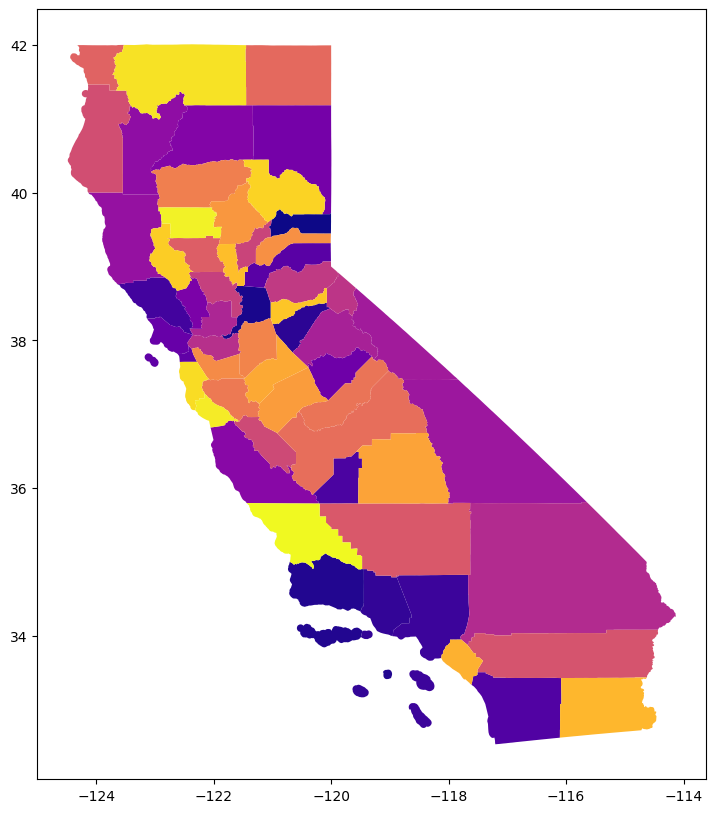

In [35]:
CA_county.plot(figsize = (10,10), linewidth = 0.8, cmap = 'plasma')

In [36]:
CA_county.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [37]:
starbucks_locations = pd.read_csv("starbucks_locations.csv")
starbucks_locations.head()

,Store Number,Store Name,Address,City,Longitude,Latitude
0,10429-100710,Palmdale & Hwy 395,14136 US Hwy 395 Adelanto CA,Adelanto,-117.40,34.51
1,635-352,Kanan & Thousand Oaks,5827 Kanan Road Agoura CA,Agoura,-118.76,34.16
2,74510-27669,Vons-Agoura Hills #2001,5671 Kanan Rd. Agoura Hills CA,Agoura Hills,-118.76,34.15
3,29839-255026,Target Anaheim T-0677,8148 E SANTA ANA CANYON ROAD AHAHEIM CA,AHAHEIM,-117.75,33.87
4,23463-230284,Safeway - Alameda 3281,2600 5th Street Alameda CA,Alameda,-122.28,37.79


In [38]:
starbucks_locations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2821 entries, 0 to 2820
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store Number  2821 non-null   object 
 1   Store Name    2821 non-null   object 
 2   Address       2821 non-null   object 
 3   City          2821 non-null   object 
 4   Longitude     2816 non-null   float64
 5   Latitude      2816 non-null   float64
dtypes: float64(2), object(4)
memory usage: 132.4+ KB


In [39]:
print(starbucks_locations.dtypes)


Store Number     object
Store Name       object
Address          object
City             object
Longitude       float64
Latitude        float64
dtype: object


In [40]:
starbucks_locations.isna().sum()

Store Number    0
Store Name      0
Address         0
City            0
Longitude       5
Latitude        5
dtype: int64

In [41]:
starbucks_locations = starbucks_locations.dropna(subset=['Longitude', 'Latitude'])

In [42]:
starbucks_locations.isna().sum()

Store Number    0
Store Name      0
Address         0
City            0
Longitude       0
Latitude        0
dtype: int64

In [43]:
# Convertir le dataframe en geodataframe

starbucks = gpd.GeoDataFrame(starbucks_locations, geometry=gpd.points_from_xy(starbucks_locations.Longitude, starbucks_locations.Latitude))

# Definir le systeme de references de coordonnees crs sur ESPG 4326

starbucks.crs = {'init':'epsg:4326'}

# Afficher

starbucks.head()

c:\Users\pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\pyproj\crs\crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


,Store Number,Store Name,Address,City,Longitude,Latitude,geometry
0,10429-100710,Palmdale & Hwy 395,14136 US Hwy 395 Adelanto CA,Adelanto,-117.40,34.51,POINT (-117.40000 34.51000)
1,635-352,Kanan & Thousand Oaks,5827 Kanan Road Agoura CA,Agoura,-118.76,34.16,POINT (-118.76000 34.16000)
2,74510-27669,Vons-Agoura Hills #2001,5671 Kanan Rd. Agoura Hills CA,Agoura Hills,-118.76,34.15,POINT (-118.76000 34.15000)
3,29839-255026,Target Anaheim T-0677,8148 E SANTA ANA CANYON ROAD AHAHEIM CA,AHAHEIM,-117.75,33.87,POINT (-117.75000 33.87000)
4,23463-230284,Safeway - Alameda 3281,2600 5th Street Alameda CA,Alameda,-122.28,37.79,POINT (-122.28000 37.79000)


In [57]:
plot_starbucks = starbucks.City.value_counts()
plot_starbucks

City
San Diego        135
Los Angeles      127
San Francisco     89
San Jose          85
Sacramento        63
                ... 
Mira Loma          1
Mission Hills      1
MISSION VIEJO      1
Monterey Park      1
Yucca Valley       1
Name: count, Length: 529, dtype: int64

In [44]:
starbucks.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 2816 entries, 0 to 2820
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Store Number  2816 non-null   object  
 1   Store Name    2816 non-null   object  
 2   Address       2816 non-null   object  
 3   City          2816 non-null   object  
 4   Longitude     2816 non-null   float64 
 5   Latitude      2816 non-null   float64 
 6   geometry      2816 non-null   geometry
dtypes: float64(2), geometry(1), object(4)
memory usage: 176.0+ KB


<Axes: >

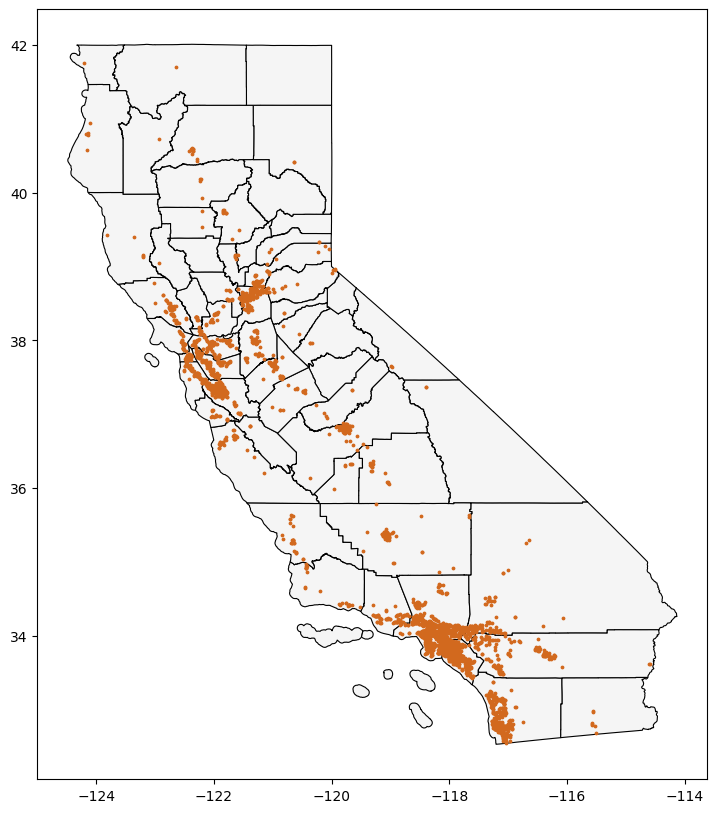

In [45]:
# Definissons la carte de base
ax = CA_county.plot(figsize=(10,10), color='whitesmoke', edgecolor='black', linewidth = 0.8)

# Mettons les emplacements des magasins sur la cartes
starbucks.plot(ax=ax, markersize = 3, color = 'chocolate') # mediumblue chocolate

In [46]:
# Coordonnées centrales de la Californie
california_coords = [36.7783, -119.4179]

# Créer une carte centrée sur la Californie
m_california = folium.Map(location=california_coords, tiles='openstreetmap', zoom_start=6)

# Afficher la carte
m_california

In [52]:
m_california_1 = folium.Map(location=california_coords, tiles='cartodbpositron', zoom_start=6)

# Ajoutons les bulles a la carte de base
for i in range(0, len(starbucks_locations)):
    Circle(
        location=[starbucks_locations.iloc[i]['Latitude'], starbucks_locations.iloc[i]['Longitude']],
        radius=20,
        color = "#179BAE"
    ).add_to(m_california_1)

m_california_1

In [54]:
m_california_2 = folium.Map(location=california_coords, tiles='cartodbpositron', zoom_start=6)

HeatMap(data=starbucks_locations[['Latitude', 'Longitude']], radius=10).add_to(m_california_2)

m_california_2

In [59]:
m_california_3 = folium.Map(location=california_coords, tiles='cartodbpositron', zoom_start=6)

Choropleth(geo_data=starbucks.__geo_interface__, 
           data=plot_starbucks, 
           key_on="feature.id", 
           fill_color='plasma', 
           legend_name='Major criminal incidents (Jan-Aug 2018)'
          ).add_to(m_california_3)


m_california_3